In [1]:
from typing import Literal

import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

import cliffordea
from cliffordea.accept import PauliMask
from cliffordea.enum.types import LogicalTriple

# turn figures from blurry png to svg
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

PLOT_STATES: list[Literal['Z', 'S', 'T']] = ['S', 'T']
NOISE_LEVEL = 1e-3

# Getting the Data
Analysing the fault configurations of the distance-3 and -5 double checks up to fault count 5.

In [2]:
PLOT_STATES = ('S', 'T')
daf_triples = [(3, 6, 0), (5, 19, 0)]
combinators: dict[tuple[int, int, int], cliffordea.enum.FaultCombinator] = {}
kept_effects: dict[tuple[int, int, int], dict[str, list[dict[PauliMask, LogicalTriple]]]] = {}

The below cell takes about 17 s in total to run.

In [3]:
for distance, ancilla_count, flag_count in daf_triples:
    circuit = cliffordea.enum.circuits.DoubleCheck(
        distance=distance,
        ancilla_count=ancilla_count,
        flag_count=flag_count,
    )
    noisy_circuit = cliffordea.enum.noise.uniformly_depolarize(
        circuit.INNER_CIRCUIT,
        NOISE_LEVEL,
    )
    logical_analyzer = cliffordea.accept.CliffordLogicalAnalyzer(
        data_indices=circuit.DATA_INDICES,
        stabilizer_generators=circuit.STABILIZER_GENERATORS_RESTRICTED,
        logical_s=circuit.LOGICAL_S,
    )
    combinators[distance, ancilla_count, flag_count] = cliffordea.enum.FaultCombinator(
        noisy_circuit,
        print_progress=True,
    )
    kept_effects[distance, ancilla_count, flag_count] = combinators[distance, ancilla_count, flag_count].get_kept_effects(
        logical_analyzer=logical_analyzer,
        max_fault_count=5,
        cultivated_states=PLOT_STATES,
        # print_progress=True,
    )

Finished enumerating all faults. FaultCombinator with 158 faults distributed among 19 detector signatures.
Finished enumerating all faults. FaultCombinator with 452 faults distributed among 58 detector signatures.


In [4]:
summary = pd.concat([
    combinator.summarize_contributions(kept_effects[key])
    for key, combinator in combinators.items()
], axis=0, keys=combinators.keys(), names=['distance', 'ancilla_count', 'flag_count'])
summary

configuration_count  \
                                                                            benign   
distance ancilla_count flag_count cultivated_state fault_count                       
3        6             0          S                0                             1   
                                                   1                             2   
                                                   2                            34   
                                                   3                          1175   
                                                   4                         20545   
                                                   5                        341799   
                                  T                0                             1   
                                                   1                             2   
                                                   2                            37   
                                                   3                          1436   
                                                   4                         30324   
                                                   5                        597820   
5        19            0          S                0                             1   
                                                   1                             2   
                                                   2                            28   
                                                   3                          1823   
                                                   4                         36981   
                                                   5                        631144   
                                  T                0                             1   
                                                   1                             2   
                                                   2                            28   
                                                   3                          1872   
                                                   4                         39618   
                                                   5                        737342   

                                                                          \
                                                               malignant   
distance ancilla_count flag_count cultivated_state fault_count             
3        6             0          S                0                   0   
                                                   1                   0   
                                                   2                   0   
                                                   3                  82   
                                                   4                2108   
                                                   5               63040   
                                  T                0                   0   
                                                   1                   0   
                                                   2                   4   
                                                   3                 415   
                                                   4               12869   
                                                   5              349162   
5        19            0          S                0                   0   
                                                   1                   0   
                                                   2                   0   
                                                   3                   0   
                                                   4                   0   
                                                   5                1312   
                                  T                0                   0   
                                                   1                

# Plotting the Data

In [5]:
color_map = {'T': 'tab:orange', 'S': 'tab:blue'}
style_map = {3: '--', 5: '-'}
color_func = lambda flag_count: 'tab:blue' if flag_count else 'tab:orange'

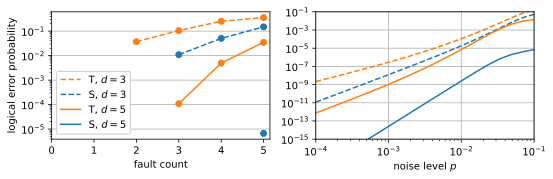

In [ ]:
x = 1.3
fig = plt.figure(figsize=(2*3*x, 2*x))

ax = plt.subplot(121)
for (distance, ancilla_count, flag_count), group in summary['weight', 'malignant_probability'].groupby( # type: ignore
    level=['distance', 'ancilla_count', 'flag_count']
):
    if flag_count:
        continue
    distance: int
    group.replace(0, np.nan, inplace=True)  # avoid plotting zeroes on log scale
    for state, color in color_map.items():
        subgroup = group.loc[distance, ancilla_count, flag_count, state]
        plt.plot(
            subgroup.index.get_level_values('fault_count'),
            subgroup,
            label=f'{state}, $d = {distance}$',
            color=color_map[state],
            linestyle=style_map.get(distance),
            marker='o',
        )
plt.yscale('log')
plt.xticks(summary.index.get_level_values('fault_count').unique())
plt.grid(axis='y')
plt.legend(framealpha=1, markerscale=0, loc='lower left')
plt.xlabel('fault count')
plt.ylabel('logical error probability')

ax: Axes = plt.subplot(122)
x_min, x_max = 1e-4, 1e-1
noise_levels = np.geomspace(x_min, x_max, 20)
for (distance, ancilla_count, flag_count), combinator in combinators.items():
    if flag_count:
        continue
    for state, color in color_map.items():
        y = combinator.error_rates_per_kept_shot(
            kept_effects[distance, ancilla_count, flag_count][state],
            noise_levels=noise_levels,
        )
        plt.plot(
            noise_levels,
            y,
            marker=None,
            label=fr'{state}, $d = {distance}$',
            linestyle=style_map[distance],
            color=color,
        )
plt.loglog()
ax.grid(True, which='major')
ax.set_xlim(x_min, x_max)
ax.set_xlabel('noise level $p$')
# y_min, y_max = plt.ylim()
ax.set_ylim(1e-15, 1e-1)
ax.yaxis.set_major_locator(LogLocator(base=10, subs=(1,), numticks=10))

plt.tight_layout()

# Introspection

There are 4 malignant 2-fault configurations in the distance-3 double check:

In [7]:
malignant_configs: list[tuple[int, ...]] = []
for _, (accept_probability, fidelity, configs) in kept_effects[3, 6, 0]['T'][2].items():
    if fidelity < 1:
        malignant_configs += configs
malignant_configs

[(74, 146), (65, 148), (111, 148), (54, 150)]

In [8]:
combinators[3, 6, 0].visualize_fault_configurations(
    malignant_configs,
    diagram_type='timeline-svg',
)

interactive(children=(BoundedIntText(value=0, description='configuration', max=3), Output()), _dom_classes=('w…

<function cliffordea.enum.combinators.fault_combinator.FaultCombinator.visualize_fault_configurations.<locals>.f(configuration: int)>